## A10

<b>Data Analytics III</b>

1. Implement Simple Naïve Bayes classification algorithm using Python/R on iris.csv dataset.

2. Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset. 

Provide the codes with outputs and explain everything that you do in this step.

**Link of Dataset**

Iris: https://www.kaggle.com/datasets/saurabh00007/iriscsv

**1) Import Required Libraries**

In [45]:
# Import required libraries
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For model building
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# For evaluation
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

**2) Load the Dataset**

In [46]:
# Load the Iris dataset
df = pd.read_csv("Iris.csv")

In [47]:
# Display first 5 rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


**3) Understand Dataset Structure**

In [48]:
# Dimmensions of dataset
df.shape

(150, 6)

In [49]:
# Datatypes of each column
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [50]:
# Display info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [51]:
# Display statistical summary
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


**4) Handle missing values**

In [52]:
# Check missing values
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

<b>5) Drop Id column</b>

In [53]:
# Drop Id column
df = df.drop("Id", axis=1)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


<b>6) Define Features (X) and Target (y)</b>

Features (X):
- SepalLengthCm
- SepalWidthCm
- PetalLengthCm
- PetalWidthCm

Target (y):
- Species

In [54]:
# Independent variables (features)
X = df.iloc[:, :-1]

# Dependent variable (target)
y = df.iloc[:, -1]

<b>7) Split Dataset (Train-Test Split)(80:20)</b>

In [55]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0
)

<b>8) Apply Naïve Bayes Algorithm</b>

We use **Gaussian Naïve Bayes** because our dataset contains continuous values.

In [56]:
# Create model
model = GaussianNB()

# Train model
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


<b>9) Make Predictions</b>

In [57]:
# Predict species
y_pred = model.predict(X_test)

In [58]:
print("Predicted values:")
print(y_pred)

Predicted values:
['Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-setosa']


<b>10) Evaluate Model</b>

<b> - Compute Confusion Matrix</b>

In [59]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11  0  0]
 [ 0 13  0]
 [ 0  1  5]]


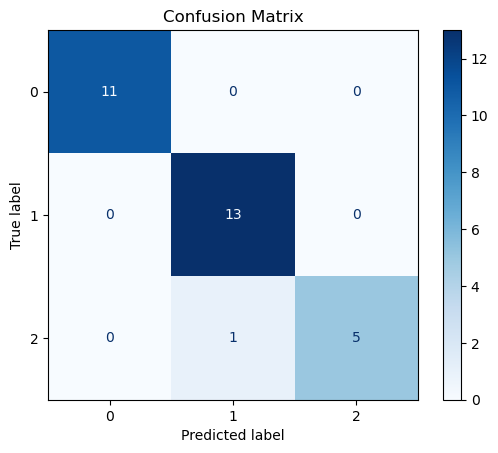

In [60]:
# Visualize Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

<b>- Performance Metrics</b>

<b>Considering "setosa" as positive class</b>

In [61]:
TP = cm[0][0]
FP = cm[1][0] + cm[2][0]
FN = cm[0][1] + cm[0][2]
TN = cm[1][1] + cm[1][2] + cm[2][1] + cm[2][2]

accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = (FP + FN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("For Setosa Class:\n")
print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

print("\nAccuracy:", np.round(accuracy, 2))
print("Error Rate:", np.round(error_rate, 2))
print("Precision:", np.round(precision, 2))
print("Recall:", np.round(recall, 2))

For Setosa Class:

TP: 11
FP: 0
TN: 19
FN: 0

Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


<b>Considering "versicolor" as positive class</b>

In [62]:
TP = cm[1][1]
FP = cm[0][1] + cm[2][1]
FN = cm[1][0] + cm[1][2]
TN = cm[0][0] + cm[0][2] + cm[2][0] + cm[2][2]

accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = (FP + FN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("For Versicolor Class:\n")
print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

print("\nAccuracy:", np.round(accuracy, 2))
print("Error Rate:", np.round(error_rate, 2))
print("Precision:", np.round(precision, 2))
print("Recall:", np.round(recall, 2))

For Versicolor Class:

TP: 13
FP: 1
TN: 16
FN: 0

Accuracy: 0.97
Error Rate: 0.03
Precision: 0.93
Recall: 1.0


<b>Considering "verginica" as positive class</b>

In [63]:
TP = cm[2][2]
FP = cm[0][2] + cm[1][2]
FN = cm[2][0] + cm[2][1]
TN = cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1]

accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = (FP + FN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print("For Verginica Class:\n")
print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

print("\nAccuracy:", np.round(accuracy, 2))
print("Error Rate:", np.round(error_rate, 2))
print("Precision:", np.round(precision, 2))
print("Recall:", np.round(recall, 2))

For Verginica Class:

TP: 5
FP: 0
TN: 24
FN: 1

Accuracy: 0.97
Error Rate: 0.03
Precision: 1.0
Recall: 0.83


<b>Overall Accuracy & Error</b>

In [64]:
diagonal = cm[0][0] + cm[1][1] + cm[2][2]
total = cm[0][0] + cm[0][1] + cm[0][2] + cm[1][0] + cm[1][1] + cm[1][2] + cm[2][0] + cm[2][1] + cm[2][2]

acc = diagonal / total
err = 1 - acc

print("Accuracy: ", np.round(acc, 2))
print("Error: ", np.round(err, 2))

Accuracy:  0.97
Error:  0.03


<b><i>Using libraries for calculating metrics easily</i></b>

In [65]:
a = accuracy_score(y_test, y_pred)
print("Accuracy: ", np.round(a, 2))
print("Error rate: ",np.round(1-a, 2))

Accuracy:  0.97
Error rate:  0.03


In [66]:
# Detailed classification report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       0.93      1.00      0.96        13
 Iris-virginica       1.00      0.83      0.91         6

       accuracy                           0.97        30
      macro avg       0.98      0.94      0.96        30
   weighted avg       0.97      0.97      0.97        30

